In [1]:
import pandas as pd 
 
df = pd.read_csv("data/house_prices.csv") 
df.shape 


(187531, 21)

In [2]:
df.head() 


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info() 


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe() 


,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False) 

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [6]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

Number of Rows : 187531
Numeric Columns : Index , Price (in rupees), Dimensions, Plot Area
Text Columns : Title, Description, Amount(in rupees), location, Carpet Area, Status, Floor, Transaction, Furnishing, facing, overlooking, Society, Bathroom, Balcony, Car Parking, Ownership, Super Area
Columns with most missing values : Plot Area , Dimensions . with all 187531 rows missing 
                                    Society , Super Area , Car Parking . with almost 60% missing values 
                                    Carpet Area , overlooking . with 43% 
                                    facing with 37% 
                                    Ownership with almost 35% 
                                    Balcony with 26%
                                    
                                    

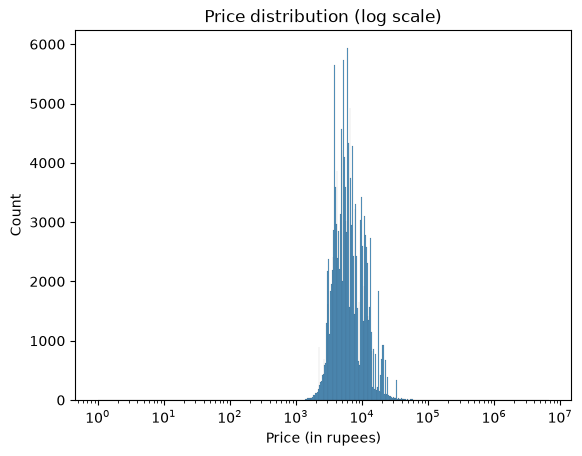

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Price (in rupees)"].dropna(), log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

This plot clearly shows the price data are right-skewed  , which means most houses are cheap compared to the rest , and few houses are expensive

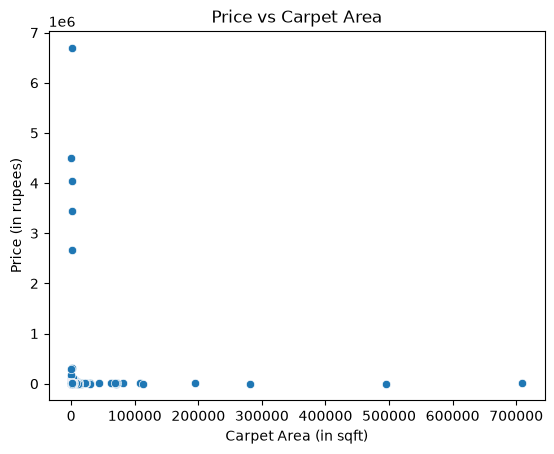

In [8]:
sns.scatterplot(x=df["Carpet Area"].str.extract(r"(\d+)")[0].astype(float), y=df["Price (in rupees)"])
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (in sqft)")
plt.show()

Most of the data are near eachother , but there is some outliers which need to be handled 

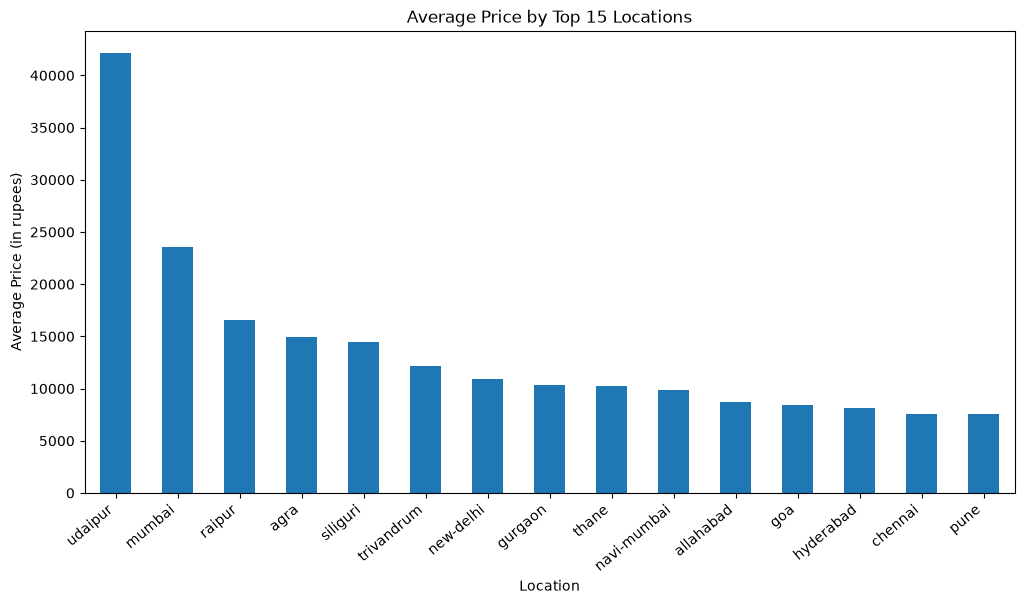

In [9]:
plt.figure(figsize=(12, 6))
df.groupby("location")["Price (in rupees)"].mean().sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Location")
plt.ylabel("Average Price (in rupees)")
plt.xticks(rotation=40, ha="right")
plt.show()

Udaipur has the most expensive houses while Pune has the cheapest according to their average price

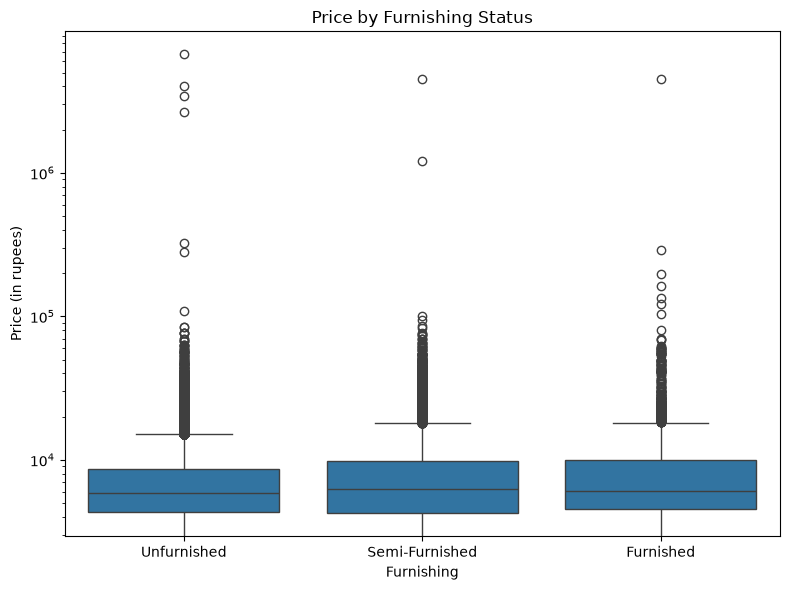

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Furnishing", y="Price (in rupees)", data=df)
plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (in rupees)")
plt.yscale("log")
plt.tight_layout()
plt.show()

Furnishing status does not show a big difference in price which isnt helpful enough , but clearly there are some outliers 

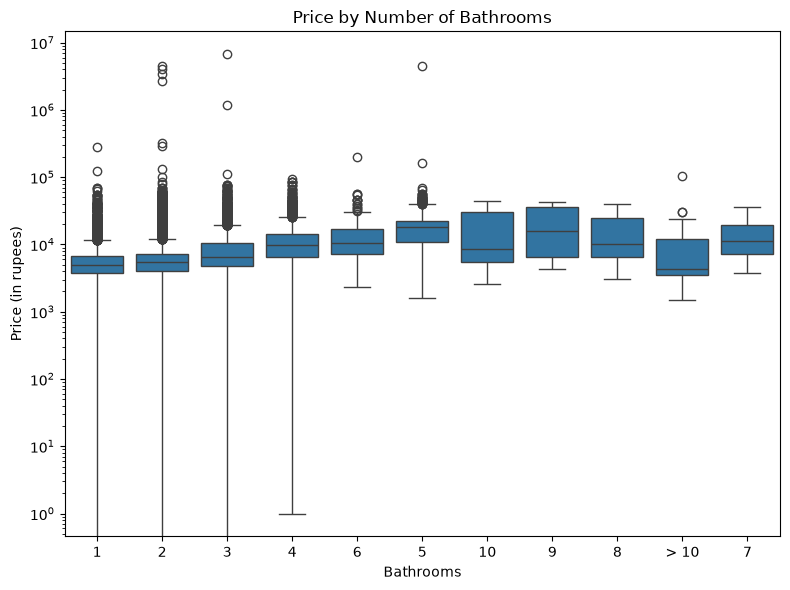

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Bathroom", y="Price (in rupees)", data=df)
plt.title("Price by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price (in rupees)")
plt.yscale("log")
plt.tight_layout()
plt.show()

As the number of bathrooms increase , the price increases, only upto 5 bathrooms . The trend gets noisy or breaks starting from 6 bathrooms.

In [12]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None


In [13]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

In [14]:
df["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

In [15]:
df['price_clean'].isnull().sum()

np.int64(0)

In [16]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        number = float(x.split()[0].replace(",", ""))
    except (ValueError, IndexError):
        return None
    if "sqm" in x:
        return number * 10.764
    return number 

In [17]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

In [18]:
df[["Carpet Area", "carpet_area_sqft"]].head(20)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [19]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if "ground" in x:
        return 0
    if "basement" in x:
        return -1
    try:
        return int(x.split()[0])
    except (ValueError, IndexError):
        return None

In [20]:
df["floor_num"] = df["Floor"].apply(parse_floor)

In [21]:
df[["Floor", "floor_num"]].head(15)

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [22]:
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")
df["car_parking"] = pd.to_numeric(df["Car Parking"], errors="coerce")

In [23]:
df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())
df["balcony"] = df["balcony"].fillna(0)
df["car_parking"] = df["car_parking"].fillna(0)

In [24]:
df[["bathroom", "balcony", "car_parking"]].isna().sum()

bathroom       0
balcony        0
car_parking    0
dtype: int64

In [25]:
df.isna().sum()

Index                     0
Title                     0
Description            2929
Amount(in rupees)         0
Price (in rupees)      7981
location                  0
Carpet Area           76325
Status                  595
Floor                  6949
Transaction              67
Furnishing             2067
facing                65736
overlooking           75825
Society              102919
Bathroom                760
Balcony               47159
Car Parking           95912
Ownership             61925
Super Area           101612
Dimensions           177847
Plot Area            177847
price_clean               0
carpet_area_sqft      76325
super_area_sqft      101612
floor_num              6949
bathroom                  0
balcony                   0
car_parking               0
dtype: int64

In [26]:
top_locations = df["location"].value_counts().head(50).index
df["location_grouped"] = df["location"].apply(lambda x: x if x in top_locations else "other")

In [27]:
df["location_grouped"].nunique()

51

In [28]:
df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area"])

In [29]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
lower_boundary = df["price_per_sqft"].quantile(0.01)
upper_boundary = df["price_per_sqft"].quantile(0.99)
df = df[(df["price_per_sqft"] >= lower_boundary) & (df["price_per_sqft"] <= upper_boundary) | (df["price_per_sqft"].isna())]

In [30]:
df.shape

(176293, 25)

In [31]:
df["price_per_sqft"].describe()

count     99968.000000
mean      12125.772152
std       13369.847504
min        2705.882353
25%        5516.450850
50%        8000.000000
75%       13020.833333
max      101503.759398
Name: price_per_sqft, dtype: float64

In [32]:
df.isna().sum()

Amount(in rupees)         0
Price (in rupees)      7833
location                  0
Carpet Area           76325
Status                  591
Floor                  6946
Transaction              65
Furnishing             2066
facing                65415
overlooking           75475
Society              102325
Bathroom                760
Balcony               47097
Car Parking           95260
Ownership             61653
Super Area           100058
price_clean               0
carpet_area_sqft      76325
super_area_sqft      100058
floor_num              6946
bathroom                  0
balcony                   0
car_parking               0
location_grouped          0
price_per_sqft        76325
dtype: int64

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([("prep", preprocessor),
                   ("reg", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [34]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

pred = model.predict(X_test)
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", root_mean_squared_error(y_test, pred))
print("R²  :", r2_score(y_test, pred))

MAE : 1354452.1815177302
RMSE: 5705804.459810556
R²  : 0.826019919539987


In [35]:
model_lr = Pipeline([("prep", preprocessor),
                      ("reg", LinearRegression())])
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", root_mean_squared_error(y_test, pred_lr))
print("R²  :", r2_score(y_test, pred_lr))

MAE : 4687508.291751591
RMSE: 8890567.46596214
R²  : 0.5775992088212984


In [36]:
from sklearn.ensemble import GradientBoostingRegressor
model_gb = Pipeline ([("prep" , preprocessor) , ("reg" , GradientBoostingRegressor(n_estimators=200 , random_state= 67 ))])
model_gb.fit(X_train, y_train)
pred_gb = model_gb.predict(X_test)
print("MAE :", mean_absolute_error(y_test, pred_gb))
print("RMSE:", root_mean_squared_error(y_test, pred_gb))
print("R²  :", r2_score(y_test, pred_gb))

MAE : 3195780.583847634
RMSE: 6771222.861789361
R²  : 0.7549808803635172


I compared three models: Linear Regression, Random Forest, and Gradient Boosting . Random Forest performed best in all metrics (MAE: 1.35M, RMSE:5.71M, R² = 0.826), followed by Gradient Boosting (R² = 0.755) and Linear Regression (R² = 0.578). Random Forest and Gradient Boosting outperformed the linear baseline, confirming non-linear feature interactions matter for this dataset. Gradient Boosting's underperformance relative to Random Forest is likely due to using default hyperparameters — it might need some tuning (learning rate, tree depth, number of estimators) to reach its full potential, whereas Random Forest tends to perform well with defaults. I select Random Forest as the final model for this dataset predictions.

In [37]:
#from sklearn.model_selection import cross_val_score
#import numpy as np
#cross_validation_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
#print("R² scores per fold:",cross_validation_scores)
#print("Mean R²:", cross_validation_scores.mean())
#print("Std R²:", cross_validation_scores.std())

Worst Score so far , so we will skip this model

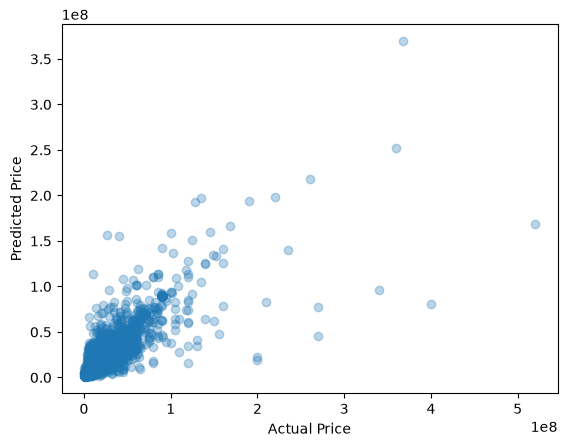

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [39]:
import joblib

joblib.dump(model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [7708702.18253968]


In [40]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))

In [41]:
import sklearn
print(sklearn.__version__)

1.9.0
